This notebook helps analyse which modelling family is best.
It utilises the fold level results to do so. 

EDIT CHECK

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from pathlib import Path
import joblib

In [ ]:
df = pd.read_csv("nestedcv_surrogate_shufflesplit_fold_level_results.csv") 


summary = (
    df.groupby("model")["val_R2"]
      .agg(["mean", "std", "count"])
      .sort_values("mean", ascending=False)
)

print(summary)

                               mean       std  count
model                                               
LGBMRegressor              0.412825  0.078946      2
SVR                        0.391644  0.189267     23
Ridge                      0.362713  0.173220      4
XGBRegressor               0.311564  0.181379      6
GradientBoostingRegressor  0.293854  0.152559      4
CatBoostRegressor          0.240908  0.047126      4
LinearRegression           0.117298       NaN      1
RandomForestRegressor      0.089427  0.436619      2
ElasticNet                -0.726447  2.363649      4


In [ ]:
df = pd.read_csv("LATEST_results/nestedcv_surrogate_shufflesplit_fold_level_results.csv") 


# Basic aggregation by model
agg = (df.groupby("model")["val_R2"]
         .agg(count="count", mean="mean", std="std", median="median")
         .sort_values(["mean", "median"], ascending=False))

print(agg)

# how often each model wins within a repeat - (winner = best outer_R2 among the 5 outer folds inside each repeat)
winners = (df.loc[df.groupby("repeat")["val_R2"].idxmax()] #MIGHT BE WRONG - CHECK THIS
             .groupby("model")["val_R2"]
             .agg(win_count="count", win_mean="mean")
             .sort_values(["win_count", "win_mean"], ascending=False))

print("\nWinners by repeat (best outer_R2 within each repeat):")
print(winners)

                           count      mean       std    median
model                                                         
LGBMRegressor                  2  0.412825  0.078946  0.412825
SVR                           23  0.391644  0.189267  0.374710
Ridge                          4  0.362713  0.173220  0.380795
XGBRegressor                   6  0.311564  0.181379  0.335634
GradientBoostingRegressor      4  0.293854  0.152559  0.326443
CatBoostRegressor              4  0.240908  0.047126  0.245922
LinearRegression               1  0.117298       NaN  0.117298
RandomForestRegressor          2  0.089427  0.436619  0.089427
ElasticNet                     4 -0.726447  2.363649  0.433447

Winners by repeat (best outer_R2 within each repeat):
              win_count  win_mean
model                            
SVR                   8  0.562426
Ridge                 1  0.535172
XGBRegressor          1  0.410003


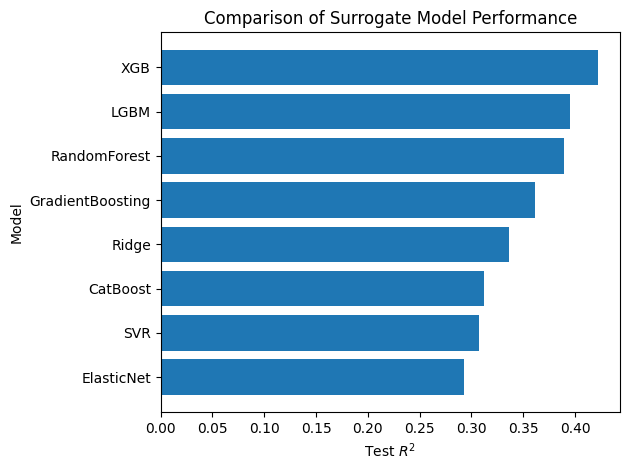

In [ ]:
df = pd.read_csv("LATEST_final_surrogate_all_models_summary.csv")

df = df.sort_values("holdout_r2", ascending=True)

plt.figure()

plt.barh(df["model"], df["holdout_r2"])

plt.xlabel("Test $R^2$")
plt.ylabel("Model")
plt.title("Comparison of Surrogate Model Performance")

plt.tight_layout()

plt.savefig("LATEST_model_comparison_r2.png", dpi=300)

plt.show()

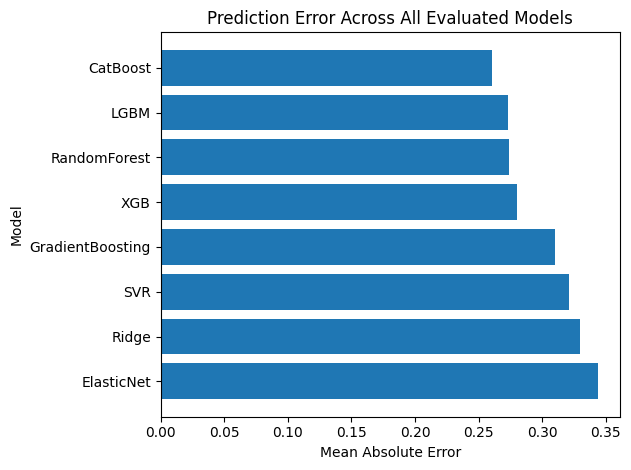

In [22]:
plt.figure()

df = df.sort_values("holdout_mae", ascending=False)

plt.barh(df["model"], df["holdout_mae"])

plt.xlabel("Mean Absolute Error")
plt.ylabel("Model")
plt.title("Prediction Error Across All Evaluated Models")

plt.tight_layout()
plt.savefig("LATEST_model_comparison_mae.png", dpi=300)

In [ ]:
RESULTS_CSV = "LATEST_final_surrogate_all_models_summary.csv"
BEST_MODEL_PIPELINE = "final_surrogate_xgb_pipeline.joblib"  # change if needed
OUT_DIR = Path("results_artifacts") 


def make_pretty_model_name(name: str) -> str:
    mapping = {
        "ElasticNet": "ElasticNet",
        "Ridge": "Ridge",
        "RandomForest": "Random Forest",
        "GradientBoosting": "Gradient Boosting",
        "LGBM": "LightGBM",
        "CatBoost": "CatBoost",
        "XGB": "XGBoost",
        "SVR": "SVR",
    }
    return mapping.get(name, name)


def load_results(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    df["pretty_model"] = df["model"].apply(make_pretty_model_name)
    return df


def save_clean_table(df: pd.DataFrame) -> pd.DataFrame:
    table_df = df[["pretty_model", "best_score", "holdout_r2", "holdout_mae", "holdout_mse"]].copy()
    table_df.columns = ["Model", "CV_R2", "Test_R2", "MAE", "MSE"]
    table_df = table_df.sort_values("Test_R2", ascending=False).reset_index(drop=True)
    table_df.to_csv(OUT_DIR / "LATEST_model_comparison_clean.csv", index=False)
    return table_df


def save_latex_table(table_df: pd.DataFrame) -> None:
    latex = table_df.to_latex(
        index=False,
        float_format="%.3f",
        caption="Performance of surrogate models on the held-out test set.",
        label="tab:model_comparison",
    )
    with open(OUT_DIR / "LATEST_model_comparison_table.tex", "w") as f:
        f.write(latex)


def plot_metric_barh(df: pd.DataFrame, metric: str, xlabel: str, filename: str) -> None:
    plot_df = df.sort_values(metric, ascending=True)

    plt.figure(figsize=(8, 5))
    plt.barh(plot_df["pretty_model"], plot_df[metric])
    plt.xlabel(xlabel)
    plt.ylabel("Model")
    plt.tight_layout()
    plt.savefig(OUT_DIR / filename, dpi=300, bbox_inches="tight")
    plt.close()


def get_selected_feature_names_from_pipeline(pipe) -> list[str]:
    prep = pipe.named_steps["prep"]
    fs = pipe.named_steps["fs"]

    feature_names = prep.named_steps["ct"].get_feature_names_out()
    support_mask = fs.get_support()

    selected_names = np.array(feature_names)[support_mask].tolist()
    return selected_names


def plot_feature_importance(pipeline_path: str, top_n: int = 20) -> None:
    pipe = joblib.load(pipeline_path)

    model = pipe.named_steps["model"]
    selected_names = get_selected_feature_names_from_pipeline(pipe)

    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
    elif hasattr(model, "coef_"):
        coef = model.coef_
        importances = np.abs(coef.ravel())
    else:
        print(f"Model type {type(model).__name__} has no built-in feature importance.")
        return

    feat_df = pd.DataFrame({
        "feature": selected_names,
        "importance": importances,
    }).sort_values("importance", ascending=False)

    feat_df.to_csv(OUT_DIR / "LATEST_feature_importance_full.csv", index=False)

    top_df = feat_df.head(top_n).sort_values("importance", ascending=True)

    plt.figure(figsize=(10, 6))
    plt.barh(top_df["feature"], top_df["importance"])
    plt.xlabel("Importance")
    plt.ylabel("Selected feature")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "LATEST_feature_importance_top20.png", dpi=300, bbox_inches="tight")
    plt.close()


def main():
    df = load_results(RESULTS_CSV)
    table_df = save_clean_table(df)
    save_latex_table(table_df)

    # plot_metric_barh(
    #     df,
    #     metric="holdout_r2",
    #     xlabel="Test $R^2$",
    #     filename="LATEST_model_comparison_r2.png",
    # )

    # plot_metric_barh(
    #     df,
    #     metric="holdout_mae",
    #     xlabel="Mean Absolute Error",
    #     filename="LATEST_model_comparison_mae.png",
    # )

    # plot_feature_importance(BEST_MODEL_PIPELINE, top_n=20)

    print("Saved outputs to:", OUT_DIR.resolve())
    print(table_df)


if __name__ == "__main__":
    main()

Saved outputs to: /Users/asmita/Desktop/StableDiffusionBias/surrogate_models/models/version2/results_artifacts
               Model     CV_R2   Test_R2       MAE       MSE
0            XGBoost  0.293900  0.422310  0.280468  0.178035
1           LightGBM  0.149399  0.395583  0.273199  0.186271
2      Random Forest  0.149310  0.389304  0.274271  0.188206
3  Gradient Boosting  0.237324  0.360972  0.309951  0.196938
4              Ridge  0.194227  0.336422  0.330107  0.204504
5           CatBoost  0.246956  0.312186  0.260800  0.211973
6                SVR  0.277362  0.307686  0.321461  0.213360
7         ElasticNet  0.250174  0.292925  0.344049  0.217909


In [ ]:
# Extract parameters
pipe = joblib.load("latest_trained_models/final_surrogate_xgb_pipeline.joblib")

# Extract best params
best_params = pipe.named_steps["model"].get_params()
print(best_params)
k_best = pipe.named_steps["fs"].k
print('k best', k_best)

{'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.8, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.1, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 3, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 500, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 1.0, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}
k best 80
